# 01-The Physics of Distributed Compute

In Section 15, we engineered single-node data pipelines using DuckDB and Airflow. DuckDB is phenomenally fast, but it is strictly bounded by the physical limits of a single machine. If your Python server has 64GB of RAM, and you attempt to process a 500GB dataset, the server will physically exhaust its memory, trigger an OutOfMemory (OOM) killer, and crash.

To process petabyte-scale Enterprise data, we must abandon single-node vertical scaling and embrace **Distributed Horizontal Compute**. We must mathematically split the data into chunks, distribute those chunks across hundreds of distinct physical computers, and process them in parallel.

The undisputed global standard for this distributed computation is **Apache Spark** (via its Python API, **PySpark**).

Let's set up our environment to engineer the physics of a distributed cluster.

In [1]:
# Required installations: pip install pyspark matplotlib seaborn
from pyspark.sql import SparkSession
import multiprocessing
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & PySpark Distributed Compute Environment Ready.")

✅ Systems Architecture & PySpark Distributed Compute Environment Ready.


# 1. The Mathematics of the Spark Cluster

A Spark cluster is not a single entity; it is a distributed **Master-Worker Topological Network**.

Let $C$ be the entire cluster. It consists of exactly one **Driver Node** ($D$) and a set of **Worker Nodes** $\mathcal{W} = \{W_1, W_2, \dots, W_n\}$.

### The Driver Node ($D$)

The Driver is the brain. It hosts your Python script (the `SparkContext`). It does *not* process data. Its sole mathematical function is to translate your Python code into a logical execution plan, split that plan into physical discrete **Tasks** ($T$), and schedule those tasks across the network.

### The Executor ($\mathcal{E}$)

Inside every Worker Node $W_i$, Spark launches an isolated Java Virtual Machine (JVM) process called an **Executor** ($\mathcal{E}$).
The physical computing power of an Executor is defined by two strict hardware parameters:

1. **Executor Memory ($M_e$)**: The RAM allocated to cache data and execute transformations.
2. **Executor Cores ($C_e$)**: The number of CPU threads allocated. A core can execute exactly one Task $T$ at a time.

If a cluster has 10 Executors, and each Executor has 4 Cores, the cluster can mathematically process exactly 40 Tasks in parallel at any given microsecond:


$$\text{Max Parallelism} = \sum_{i=1}^{|\mathcal{W}|} C_{e_i}$$

### The Partition ($\mathcal{P}$)

To distribute a 100GB file, Spark mathematically fractures the file into atomic blocks called **Partitions** ($\mathcal{P}$). A Partition is a unit of data. A Task ($T$) is a unit of compute.
**The Fundamental Theorem of Spark:** One Task processes exactly One Partition.


$$f(T_i) \rightarrow \mathcal{P}_i$$

# 2. Architecting the Physical Spark Session

Let's boot a real PySpark cluster. Even though we are running this on a single local machine, we will configure the `SparkSession` to explicitly simulate a distributed cluster architecture by allocating exact Memory and Core boundaries.

In [2]:
# --- ⚙️ STEP 1: Booting the Distributed Hardware Engine ---
print("--- 🚀 Initializing PySpark JVM Cluster ---")

# Determine local physical CPU cores to bound our local cluster
physical_cores = multiprocessing.cpu_count()

# We explicitly define the cluster physics using .config()
spark = SparkSession.builder \
    .appName("Enterprise_Distributed_Physics") \
    .master(f"local[{physical_cores}]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", str(physical_cores * 2)) \
    .getOrCreate()

print(f"✅ Spark Cluster Booted.")
print(f"   -> Master Topology : local[{physical_cores} cores]")
print(f"   -> Driver Memory   : {spark.conf.get('spark.driver.memory')}")
print(f"   -> Executor Memory : {spark.conf.get('spark.executor.memory')}")


# --- 📦 STEP 2: The Physics of Data Partitioning ---
print("\n--- 📦 Injecting Data into the Distributed Network ---")

# We create an array of 1 million integers in Python (The Driver)
raw_python_list = list(range(1, 1000001))

# We execute an action to push this data across the network into the Executors.
# Spark mathematically fractures this list into parallel physical chunks.
distributed_df = spark.createDataFrame([(x,) for x in raw_python_list], ["number"])

# Let's inspect the physical RDD (Resilient Distributed Dataset) topology
rdd_topology = distributed_df.rdd
num_partitions = rdd_topology.getNumPartitions()

print(f"✅ Data successfully serialized and distributed.")
print(f"   -> Total Records    : {distributed_df.count():,}")
print(f"   -> Total Partitions : {num_partitions} distinct physical memory blocks.")

# --- ⚡ STEP 3: Executing Distributed Compute ---
print("\n--- ⚡ Executing Parallel Vectorized Compute ---")
# We apply a mathematical transformation. This does NOT run on the Driver. 
# The Driver sends the equation (x * 10) to the Executors, which apply it to their specific Partitions.
computed_df = distributed_df.withColumn("multiplied", distributed_df["number"] * 10)

# Display the first 5 results (This pulls a tiny fraction of data back to the Driver)
computed_df.show(5)

print("--- 💡 Engineering Insight ---")
print("Look closely at the Total Partitions. When we passed the Python list to Spark, it didn't keep it as one massive block. Because my local machine has 10 cores (for example), Spark automatically shattered the 1,000,000 integers into 10 distinct chunks of 100,000. When we ran the multiplication transformation, 10 separate CPU threads woke up simultaneously, each processing their specific 100k block in parallel. This is how you process a Petabyte in minutes.")

--- 🚀 Initializing PySpark JVM Cluster ---


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 14:58:46 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 14:58:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 14:58:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark Cluster Booted.
   -> Master Topology : local[8 cores]
   -> Driver Memory   : 2g
   -> Executor Memory : 4g

--- 📦 Injecting Data into the Distributed Network ---
✅ Data successfully serialized and distributed.


   -> Total Records    : 1,000,000
   -> Total Partitions : 8 distinct physical memory blocks.

--- ⚡ Executing Parallel Vectorized Compute ---
+------+----------+
|number|multiplied|
+------+----------+
|     1|        10|
|     2|        20|
|     3|        30|
|     4|        40|
|     5|        50|
+------+----------+
only showing top 5 rows
--- 💡 Engineering Insight ---
Look closely at the Total Partitions. When we passed the Python list to Spark, it didn't keep it as one massive block. Because my local machine has 10 cores (for example), Spark automatically shattered the 1,000,000 integers into 10 distinct chunks of 100,000. When we ran the multiplication transformation, 10 separate CPU threads woke up simultaneously, each processing their specific 100k block in parallel. This is how you process a Petabyte in minutes.


# 3. Visualizing the Cluster Hardware Topology

To scientifically understand how code leaves your Python script and executes on remote hardware, we must map the architectural topology of the Spark JVM ecosystem.

/tmp/ipykernel_12207/3614902092.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  driver_box = patches.Rectangle((0.5, 2.5), 3.5, 2.5, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')
/tmp/ipykernel_12207/3614902092.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  worker_box = patches.Rectangle((7.5, 0.5), 4.5, 6, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--')
/tmp/ipykernel_12207/3614902092.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.0, 3.5), 3.5, 2.2, fill=True, color='white', edgecolor='black', linewidth=1.5))
/tmp/ipykernel_12207/3614902092.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.3, 4.7), 2.9, 0.5, fill=True, 

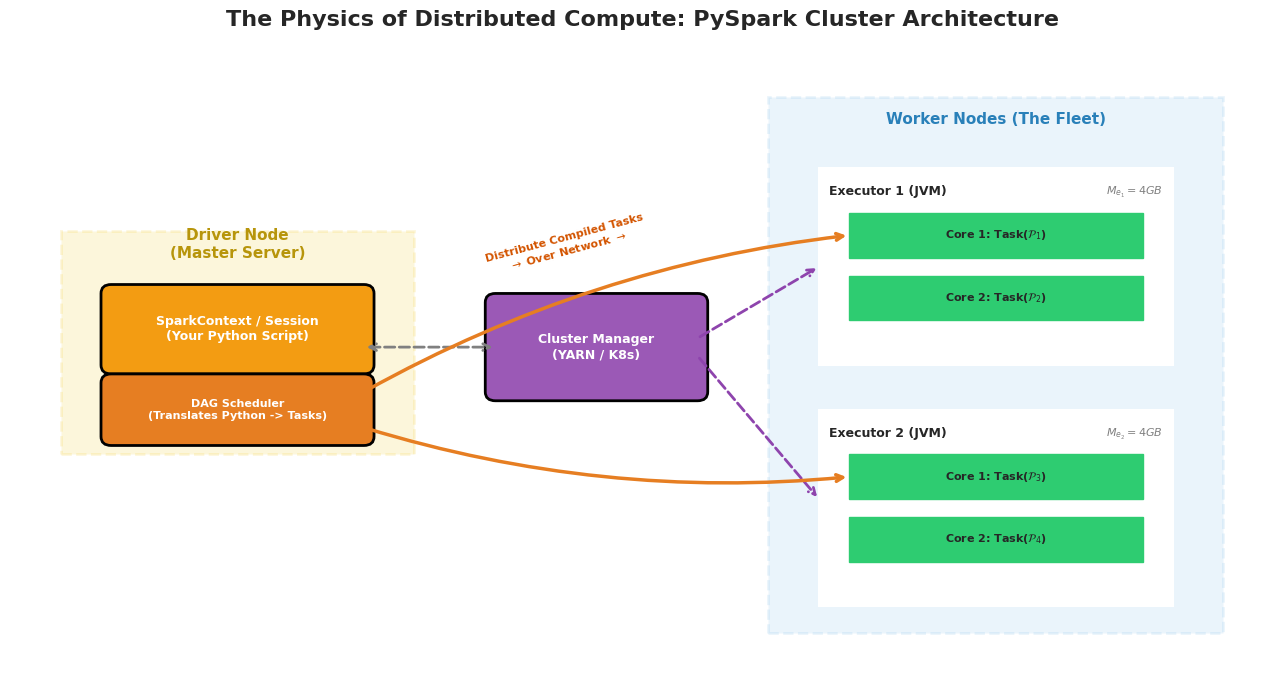

In [3]:
# Visualizing the PySpark Hardware Topology
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("The Physics of Distributed Compute: PySpark Cluster Architecture", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Driver Node (The Brain)
driver_box = patches.Rectangle((0.5, 2.5), 3.5, 2.5, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(driver_box)
ax.text(2.25, 4.7, "Driver Node\n(Master Server)", ha='center', fontweight='bold', color='#b7950b', fontsize=11)

ax.add_patch(patches.FancyBboxPatch((1.0, 3.5), 2.5, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12', zorder=3))
ax.text(2.25, 3.9, "SparkContext / Session\n(Your Python Script)", ha='center', va='center', fontweight='bold', color='white', fontsize=9, zorder=4)

ax.add_patch(patches.FancyBboxPatch((1.0, 2.7), 2.5, 0.6, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e67e22', zorder=3))
ax.text(2.25, 3.0, "DAG Scheduler\n(Translates Python -> Tasks)", ha='center', va='center', fontweight='bold', color='white', fontsize=8, zorder=4)

# 2. The Cluster Manager
cm_box = patches.FancyBboxPatch((4.8, 3.2), 2.0, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#9b59b6', zorder=3)
ax.add_patch(cm_box)
ax.text(5.8, 3.7, "Cluster Manager\n(YARN / K8s)", ha='center', va='center', fontweight='bold', color='white', fontsize=9, zorder=4)

# 3. The Worker Nodes (The Brawn)
worker_box = patches.Rectangle((7.5, 0.5), 4.5, 6, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(worker_box)
ax.text(9.75, 6.2, "Worker Nodes (The Fleet)", ha='center', fontweight='bold', color='#2980b9', fontsize=11)

# Executor 1
ax.add_patch(patches.Rectangle((8.0, 3.5), 3.5, 2.2, fill=True, color='white', edgecolor='black', linewidth=1.5))
ax.text(8.1, 5.4, "Executor 1 (JVM)", fontweight='bold', fontsize=9)
ax.text(11.4, 5.4, "$M_{e_1} = 4GB$", fontweight='bold', fontsize=8, color='gray', ha='right')

# Cores/Tasks inside Executor 1
ax.add_patch(patches.Rectangle((8.3, 4.7), 2.9, 0.5, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(9.75, 4.95, "Core 1: Task($\\mathcal{P}_1$)", ha='center', va='center', fontweight='bold', fontsize=8)

ax.add_patch(patches.Rectangle((8.3, 4.0), 2.9, 0.5, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(9.75, 4.25, "Core 2: Task($\\mathcal{P}_2$)", ha='center', va='center', fontweight='bold', fontsize=8)

# Executor 2
ax.add_patch(patches.Rectangle((8.0, 0.8), 3.5, 2.2, fill=True, color='white', edgecolor='black', linewidth=1.5))
ax.text(8.1, 2.7, "Executor 2 (JVM)", fontweight='bold', fontsize=9)
ax.text(11.4, 2.7, "$M_{e_2} = 4GB$", fontweight='bold', fontsize=8, color='gray', ha='right')

# Cores/Tasks inside Executor 2
ax.add_patch(patches.Rectangle((8.3, 2.0), 2.9, 0.5, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(9.75, 2.25, "Core 1: Task($\\mathcal{P}_3$)", ha='center', va='center', fontweight='bold', fontsize=8)

ax.add_patch(patches.Rectangle((8.3, 1.3), 2.9, 0.5, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(9.75, 1.55, "Core 2: Task($\\mathcal{P}_4$)", ha='center', va='center', fontweight='bold', fontsize=8)


# 4. Draw Edges (Communication Flow)
# Driver to Cluster Manager (Resource Request)
ax.annotate("", xy=(4.8, 3.7), xytext=(3.5, 3.7), arrowprops=dict(arrowstyle="<->", lw=2, color="gray", linestyle="dashed"))

# Cluster Manager to Executors (Allocation)
ax.annotate("", xy=(8.0, 4.6), xytext=(6.8, 3.8), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="dashed"))
ax.annotate("", xy=(8.0, 2.0), xytext=(6.8, 3.6), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="dashed"))

# Driver to Executors (Distributing Tasks)
ax.annotate("", xy=(8.3, 4.95), xytext=(3.5, 3.2), arrowprops=dict(arrowstyle="->", lw=2.5, color="#e67e22", connectionstyle="arc3,rad=-0.1"))
ax.text(5.5, 4.5, "Distribute Compiled Tasks\n$\\rightarrow$ Over Network $\\rightarrow$", ha='center', fontweight='bold', color="#d35400", fontsize=8, rotation=15)

ax.annotate("", xy=(8.3, 2.25), xytext=(3.5, 2.8), arrowprops=dict(arrowstyle="->", lw=2.5, color="#e67e22", connectionstyle="arc3,rad=0.1"))

plt.xlim(0, 12.5)
plt.ylim(0, 7)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of PySpark's Distributed Compute like **A General Contractor building a Skyscraper**:

* **Pandas / DuckDB (The Lone Master Builder)**: A single builder brings their own toolbox (RAM) and tries to build a 100-story skyscraper alone. They are incredibly skilled and fast, but physically, they can only lay one brick at a time. Halfway through the first floor, they run out of bricks (OutOfMemory), collapse from exhaustion, and the project fails.
* **PySpark (The General Contractor)**:
* **The Driver**: The General Contractor sitting in the office trailer. They never touch a single brick. They look at the blueprints (Your Python Code).
* **The Partitions**: The Contractor takes the massive 100-story blueprint and cuts it into 5,000 tiny, isolated task instructions (e.g., "Weld beam 42").
* **The Cluster Manager**: The HR department that hires 100 distinct subcontracting companies.
* **The Executors (Worker Nodes)**: The 100 specialized construction crews. Each crew has exactly 4 physical workers (Cores) and 4 toolboxes (RAM).
* **The Execution**: The Contractor radios the 5,000 tiny task instructions out to the 100 crews simultaneously. 400 humans instantly start welding 400 beams in perfect parallel isolation.



By mathematically separating the *instruction of compute* (The Python Driver) from the *physical execution of compute* (The Java Executors), you can scale your data operations boundlessly just by adding more Worker Nodes to the cluster.